# Flash / No-Flash Denoising Demo

This notebook walks through the denoising side of the paper step by step using the two files you already have:

- `algo.py`
- `structure.py`

The equations represented by each file are:

## `algo.py`
- **Eq. (2)** bilateral filter  
  \[
  A^{Base}(p)=\frac{1}{k(p)} \sum_{p' \in \Omega} g_d(p'-p)\, g_r(A_{p'}-A_p)\, A_{p'}
  \]
- **Eq. (3)** normalization term  
  \[
  k(p)=\sum_{p' \in \Omega} g_d(p'-p)\, g_r(A_{p'}-A_p)
  \]
- **Eq. (4)** joint bilateral filter  
  \[
  A^{NR}(p)=\frac{1}{k(p)} \sum_{p' \in \Omega} g_d(p'-p)\, g_r(F_{p'}-F_p)\, A_{p'}
  \]

## `structure.py`
- **Eq. (1)** ambient linearization / exposure matching  
  \[
  A_{lin}=A'_{lin}\frac{ISO_F \Delta t_F}{ISO_A \Delta t_A}
  \]
- **Eq. (5)** final denoising merge  
  \[
  A'^{NR}=(1-M)A^{NR}+MA^{Base}
  \]
- **Eq. (8)** shadow detection rule  
  \[
  M_{shad}=1 \quad \text{when} \quad |F_{lin}-A_{lin}| \le \tau_{shad}
  \]
- **Specularity heuristic** from the text: flash luminance above about **95%** of the sensor range.

This notebook first uses a **synthetic example** so everything runs immediately.  
At the end there is also a small section showing how to swap in your own flash / no-flash image pair.

In [21]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from models.algo import bilateral_filter, joint_bilateral_filter
from models.structure import (
    linearize_ambient_to_flash_space,
    detect_shadow_mask,
    detect_specularity_mask,
    detect_flash_artifact_mask,
    merge_denoised_with_mask,
    denoise_pipeline,
 )


## Step 1. Create a small synthetic flash / no-flash pair

The ambient image is darker and noisier.  
The flash image is brighter, cleaner, and includes:
- a bright specular highlight
- a region that mimics a shadow / flash artifact

This gives us a simple controlled test case for the pipeline.

In [22]:
def clip01(x):
    return np.clip(x, 0.0, 1.0)

def make_synthetic_pair(h=96, w=128, seed=7):
    rng = np.random.default_rng(seed)

    yy, xx = np.mgrid[0:h, 0:w]
    x = xx / (w - 1)
    y = yy / (h - 1)

    # Base scene with smooth illumination and a few colored objects
    scene = np.zeros((h, w, 3), dtype=np.float64)
    scene[..., 0] = 0.18 + 0.35 * x
    scene[..., 1] = 0.16 + 0.30 * y
    scene[..., 2] = 0.14 + 0.25 * (1.0 - x)

    # Warm rectangular object
    rect = (yy > 20) & (yy < 70) & (xx > 18) & (xx < 52)
    scene[rect] = np.array([0.78, 0.42, 0.26])

    # Cool circular object
    cy, cx, r = 50, 88, 18
    circ = (yy - cy) ** 2 + (xx - cx) ** 2 < r ** 2
    scene[circ] = np.array([0.22, 0.70, 0.92])

    # Neutral stripe
    stripe = (yy > 10) & (yy < 18) & (xx > 65) & (xx < 115)
    scene[stripe] = np.array([0.78, 0.78, 0.78])

    scene = clip01(scene)

    # Ambient: darker, noisier
    ambient = 0.45 * scene + 0.05
    ambient += rng.normal(0.0, 0.035, size=ambient.shape)

    # Flash: brighter, cleaner
    flash = 0.95 * scene + 0.03

    # Add a bright specular spot
    spec = np.exp(-(((yy - 28) / 7.0) ** 2 + ((xx - 38) / 6.0) ** 2))
    flash += 0.55 * spec[..., None]

    # Add a "shadow / artifact" band on the right side
    shadow_band = (xx > 94) & (yy > 18) & (yy < 82)
    flash[shadow_band] *= np.array([0.35, 0.35, 0.35])

    ambient = clip01(ambient)
    flash = clip01(flash)

    return scene, ambient, flash

scene, ambient, flash = make_synthetic_pair()
print("scene shape:", scene.shape)

scene shape: (96, 128, 3)


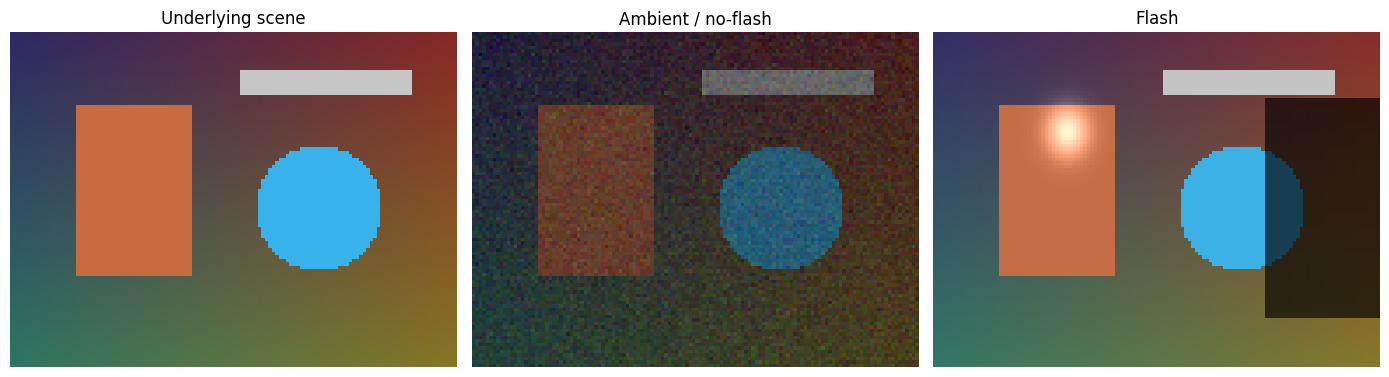

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(scene)
axes[0].set_title("Underlying scene")
axes[1].imshow(ambient)
axes[1].set_title("Ambient / no-flash")
axes[2].imshow(flash)
axes[2].set_title("Flash")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 2. Pick the denoising parameters

The exact values here are just a runnable demo.  
You can tune them later for your real images.

- `sigma_d`: spatial Gaussian width for the neighborhood
- `sigma_r_bilateral`: range Gaussian width for the bilateral filter
- `sigma_r_joint`: range Gaussian width for the joint bilateral filter
- `tau_shadow`: threshold used in the shadow detection rule

In [24]:
sigma_d = 3.0
sigma_r_bilateral = 0.10
sigma_r_joint = 0.12
tau_shadow = 0.08
radius = 5

print("sigma_d =", sigma_d)
print("sigma_r_bilateral =", sigma_r_bilateral)
print("sigma_r_joint =", sigma_r_joint)
print("tau_shadow =", tau_shadow)
print("radius =", radius)

sigma_d = 3.0
sigma_r_bilateral = 0.1
sigma_r_joint = 0.12
tau_shadow = 0.08
radius = 5


## Step 3. Run the bilateral filter from `algo.py`

This corresponds to **Eq. (2)** and **Eq. (3)**.

It denoises the ambient image using:
- spatial closeness
- intensity similarity from the ambient image itself

The result is the paper's \(A^{Base}\).

In [25]:
ambient_base = bilateral_filter(
    ambient,
    sigma_d=sigma_d,
    sigma_r=sigma_r_bilateral,
    radius=radius,
)

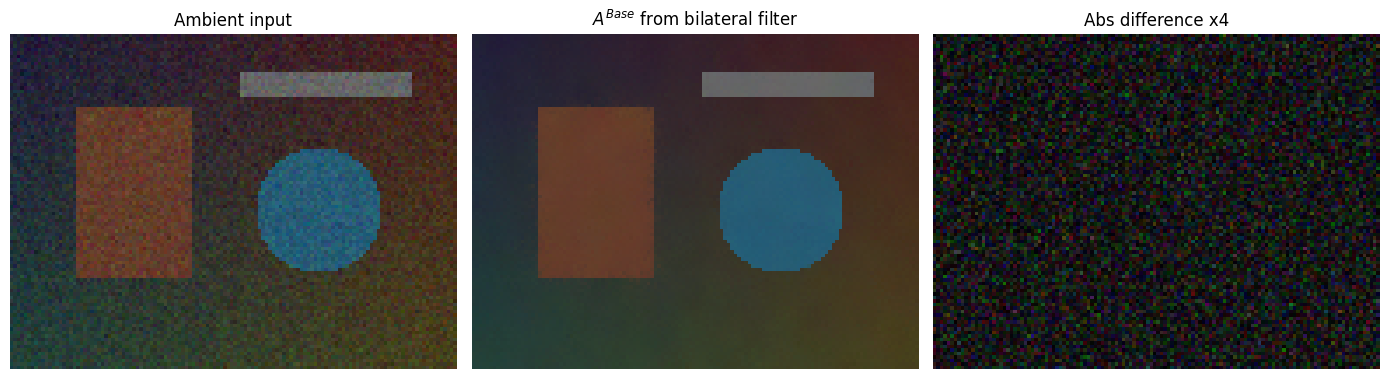

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(ambient)
axes[0].set_title("Ambient input")
axes[1].imshow(ambient_base)
axes[1].set_title(r"$A^{Base}$ from bilateral filter")
axes[2].imshow(np.clip(np.abs(ambient - ambient_base) * 4.0, 0.0, 1.0))
axes[2].set_title("Abs difference x4")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4. Run the joint bilateral filter from `algo.py`

This corresponds to **Eq. (4)**.

Now the output still averages the ambient image, but the range weights come from the **flash image**.  
That means the cleaner flash edges can guide the denoising of the noisy ambient image.

The result is the paper's \(A^{NR}\).

In [27]:
ambient_joint = joint_bilateral_filter(
    ambient,
    flash,
    sigma_d=sigma_d,
    sigma_r=sigma_r_joint,
    radius=radius,
)

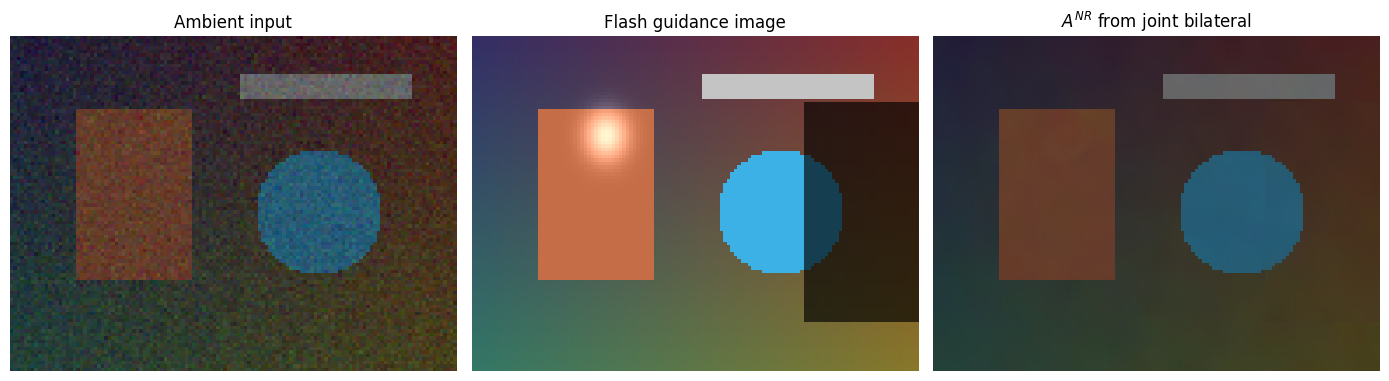

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(ambient)
axes[0].set_title("Ambient input")
axes[1].imshow(flash)
axes[1].set_title("Flash guidance image")
axes[2].imshow(ambient_joint)
axes[2].set_title(r"$A^{NR}$ from joint bilateral")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 5. Prepare "linear" versions for the mask stage

`structure.py` has a function for **Eq. (1)**:

\[
A_{lin}=A'_{lin}\frac{ISO_F \Delta t_F}{ISO_A \Delta t_A}
\]

For this synthetic demo, we will simply treat `ambient` as \(A'_{lin}\), and scale it into the flash exposure space with some made-up exposure numbers.

For real data, you would ideally start from properly linearized sensor values.

In [29]:
# Example exposure metadata used only for demonstration
iso_ambient = 800.0
t_ambient = 1.0 / 20.0
iso_flash = 100.0
t_flash = 1.0 / 60.0

ambient_linear = linearize_ambient_to_flash_space(
    ambient_linear_prime=ambient,
    iso_ambient=iso_ambient,
    t_ambient=t_ambient,
    iso_flash=iso_flash,
    t_flash=t_flash,
)

flash_linear = flash.copy()

print("ambient_linear range:", float(ambient_linear.min()), float(ambient_linear.max()))
print("flash_linear range:", float(flash_linear.min()), float(flash_linear.max()))

ambient_linear range: 0.0 0.023580999090167788
flash_linear range: 0.05705 1.0


## Step 6. Build the flash artifact masks from `structure.py`

Here we compute:

- **shadow mask** from **Eq. (8)**
- **specularity mask** from the paper's 95% luminance heuristic
- **combined artifact mask** \(M\)

The code also applies simple cleanup and feathering to mimic the overview in the paper.

In [30]:
shadow_mask = detect_shadow_mask(
    ambient_linear=ambient_linear,
    flash_linear=flash_linear,
    tau_shadow=tau_shadow,
    morph_radius=1,
    feather_radius=2,
)

specularity_mask = detect_specularity_mask(
    flash_linear=flash_linear,
    saturation_threshold=0.95,
    morph_radius=1,
    feather_radius=2,
)

shadow_mask2, specularity_mask2, artifact_mask = detect_flash_artifact_mask(
    ambient_linear=ambient_linear,
    flash_linear=flash_linear,
    tau_shadow=tau_shadow,
    saturation_threshold=0.95,
    morph_radius=1,
    feather_radius=2,
)

print("Mask consistency check:",
      np.allclose(shadow_mask, shadow_mask2),
      np.allclose(specularity_mask, specularity_mask2))

Mask consistency check: True True


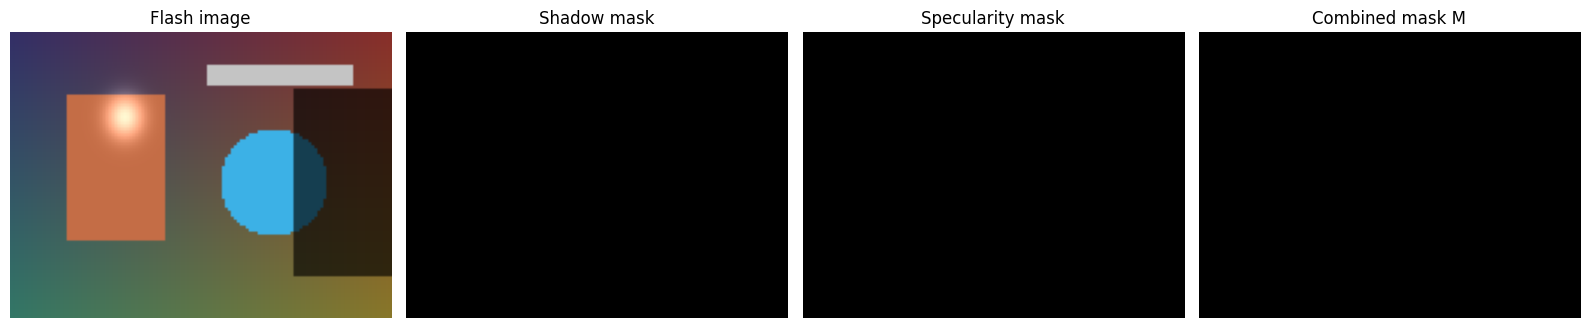

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(flash)
axes[0].set_title("Flash image")
axes[1].imshow(shadow_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Shadow mask")
axes[2].imshow(specularity_mask, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Specularity mask")
axes[3].imshow(artifact_mask, cmap="gray", vmin=0, vmax=1)
axes[3].set_title("Combined mask M")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 7. Final merge from `structure.py`

This is **Eq. (5)**:

\[
A'^{NR}=(1-M)A^{NR}+MA^{Base}
\]

Interpretation:
- where the flash guidance is safe, keep the joint bilateral result
- where the flash introduces artifacts, fall back to the plain bilateral result

In [32]:
denoised_manual = merge_denoised_with_mask(
    ambient_joint=ambient_joint,
    ambient_base=ambient_base,
    mask=artifact_mask,
)

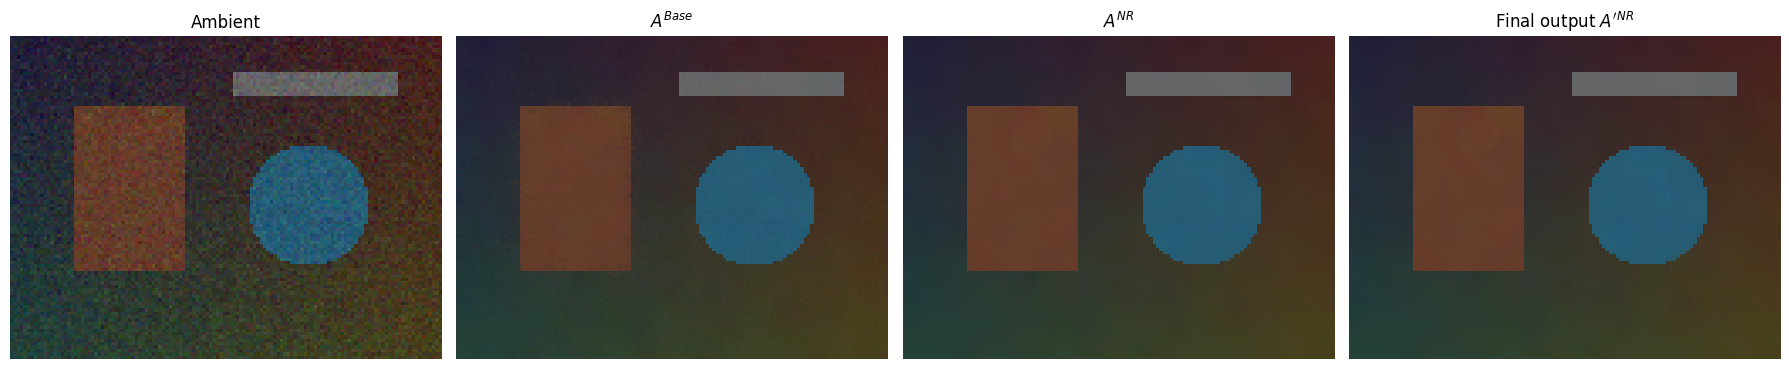

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(ambient)
axes[0].set_title("Ambient")
axes[1].imshow(ambient_base)
axes[1].set_title(r"$A^{Base}$")
axes[2].imshow(ambient_joint)
axes[2].set_title(r"$A^{NR}$")
axes[3].imshow(denoised_manual)
axes[3].set_title(r"Final output $A'^{NR}$")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 8. Run the whole pipeline at once

Now we compare the step-by-step manual construction with the single wrapper function `denoise_pipeline(...)`.

In [34]:
result = denoise_pipeline(
    ambient=ambient,
    flash=flash,
    sigma_d=sigma_d,
    sigma_r_bilateral=sigma_r_bilateral,
    sigma_r_joint=sigma_r_joint,
    ambient_linear=ambient_linear,
    flash_linear=flash_linear,
    tau_shadow=tau_shadow,
    saturation_threshold=0.95,
    radius=radius,
    morph_radius=1,
    feather_radius=2,
)

print("Manual vs pipeline final output close:",
      np.allclose(denoised_manual, result.denoised))

Manual vs pipeline final output close: True


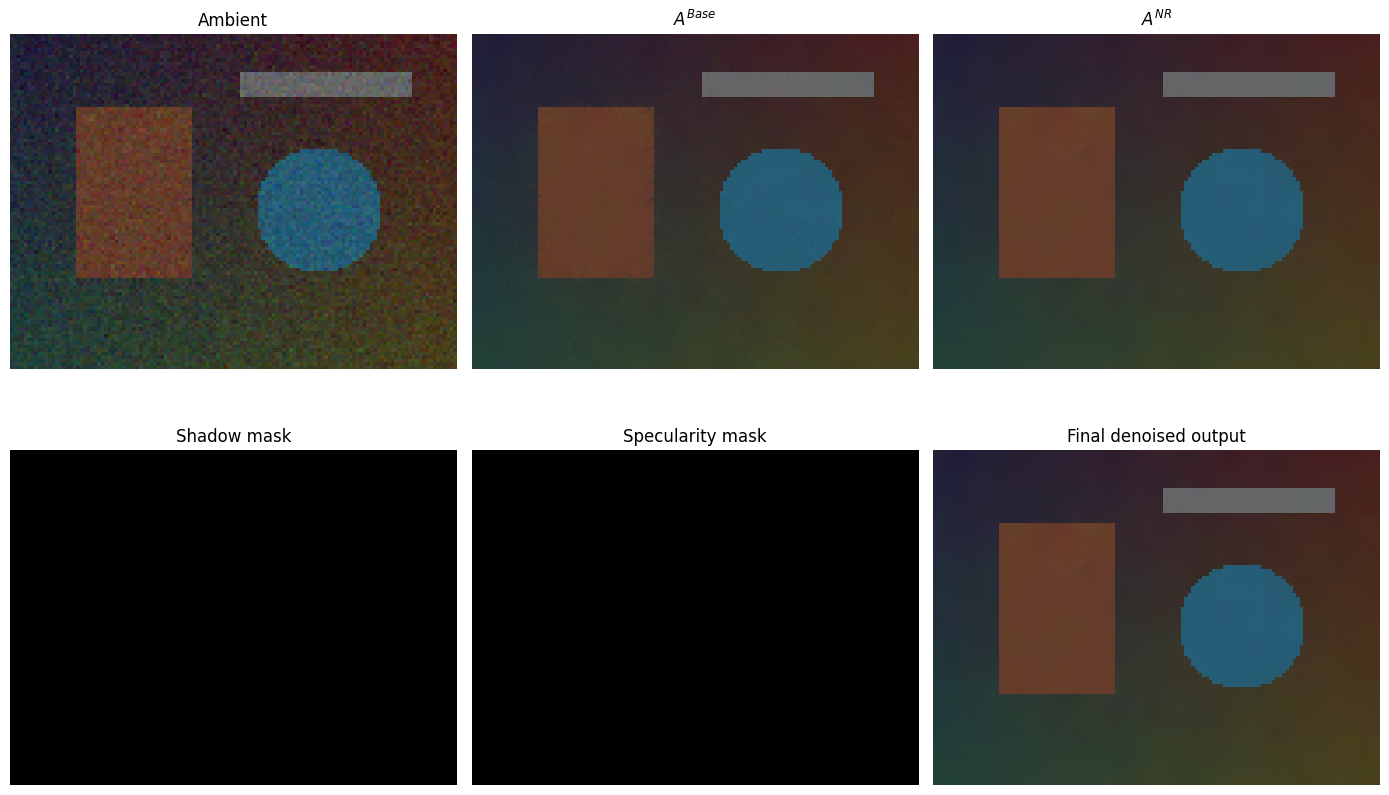

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes[0, 0].imshow(ambient)
axes[0, 0].set_title("Ambient")
axes[0, 1].imshow(result.ambient_base)
axes[0, 1].set_title(r"$A^{Base}$")
axes[0, 2].imshow(result.ambient_joint)
axes[0, 2].set_title(r"$A^{NR}$")

axes[1, 0].imshow(result.shadow_mask, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Shadow mask")
axes[1, 1].imshow(result.specularity_mask, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("Specularity mask")
axes[1, 2].imshow(result.denoised)
axes[1, 2].set_title("Final denoised output")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 9. Optional: use your own image pair

Put your own files in the same folder as the notebook, for example:

- `ambient.png`
- `flash.png`

Then run the cell below.

Notes:
1. Both images should have the same size.
2. The code below treats the loaded PNG/JPG data as normalized values in `[0, 1]`.
3. If you have real ISO / exposure metadata and better linearization, replace the simple `ambient_linear = ambient_img.copy()` part with something more physically correct.

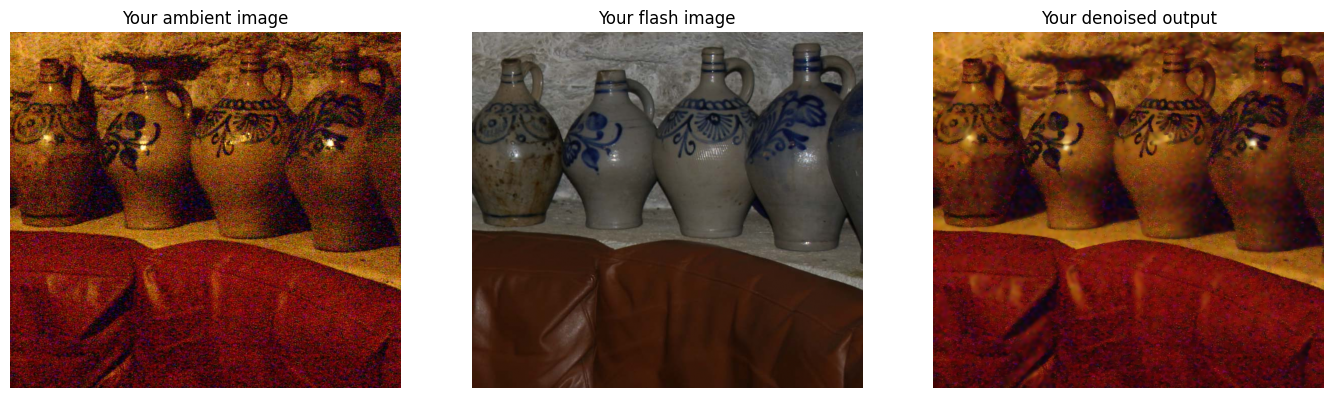

In [37]:
# Uncomment and edit this cell to use your own images

from PIL import Image

def load_rgb01(path):
    img = Image.open(path).convert("RGB")
    arr = np.asarray(img, dtype=np.float64) / 255.0
    return arr

ambient_img = load_rgb01("./samples/cave01_01_noflash.jpg")
flash_img = load_rgb01("./samples/cave01_00_flash.jpg")

if ambient_img.shape != flash_img.shape:
    raise ValueError("ambient and flash images must have the same shape")

ambient_linear_img = ambient_img.copy()
flash_linear_img = flash_img.copy()

user_result = denoise_pipeline(
    ambient=ambient_img,
    flash=flash_img,
    sigma_d=3.0,
    sigma_r_bilateral=0.10,
    sigma_r_joint=0.12,
    ambient_linear=ambient_linear_img,
    flash_linear=flash_linear_img,
    tau_shadow=0.08,
    saturation_threshold=0.95,
    radius=5,
    morph_radius=1,
    feather_radius=2,
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(ambient_img)
axes[0].set_title("Your ambient image")
axes[1].imshow(flash_img)
axes[1].set_title("Your flash image")
axes[2].imshow(user_result.denoised)
axes[2].set_title("Your denoised output")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Quick summary

- `algo.py` contains the **core filtering equations**:
  - bilateral filter: **Eq. (2), (3)**
  - joint bilateral filter: **Eq. (4)**

- `structure.py` contains the **pipeline logic**:
  - exposure matching: **Eq. (1)**
  - shadow rule: **Eq. (8)**
  - final merge: **Eq. (5)**
  - specularity detection: **95% threshold heuristic**

This notebook is meant to be easy to inspect, edit, and extend.  
If you want, the next good step is to add:
- quantitative metrics such as PSNR / SSIM
- a faster implementation
- a detail transfer stage from the paper